In [2]:
# =====================================
# 📘 1. Import required libraries
# =====================================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [3]:
# =====================================
# 📂 2. Load preprocessed data
# =====================================

# Load your saved data from the preprocess.ipynb output
X_train = pd.read_csv("processed_train.csv")
X_val = pd.read_csv("processed_val.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_val = pd.read_csv("y_val.csv").values.ravel()

print("✅ Data loaded successfully!")
print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")


✅ Data loaded successfully!
Training data shape: (43846, 41)
Validation data shape: (10962, 41)


In [3]:
# =====================================
# ⚙️ 3. Define helper functions
# =====================================

def evaluate_model(model, X_val, y_val):
    """Evaluate model and return accuracy."""
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:\n", classification_report(y_val, y_pred))
    
    # Plot confusion matrix
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    return acc


🚀 Training Logistic Regression...
✅ Logistic Regression evaluation results:
Accuracy: 0.9149

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.96     10028
           1       1.00      0.00      0.00       934

    accuracy                           0.91     10962
   macro avg       0.96      0.50      0.48     10962
weighted avg       0.92      0.91      0.87     10962



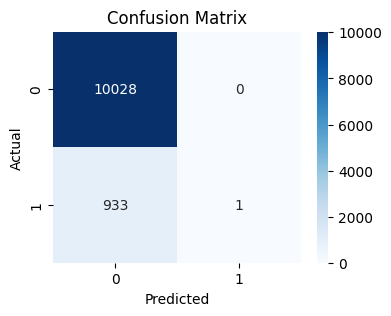

🚀 Training Random Forest...
✅ Random Forest evaluation results:
Accuracy: 0.9142

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.95     10028
           1       0.49      0.15      0.23       934

    accuracy                           0.91     10962
   macro avg       0.71      0.57      0.59     10962
weighted avg       0.89      0.91      0.89     10962



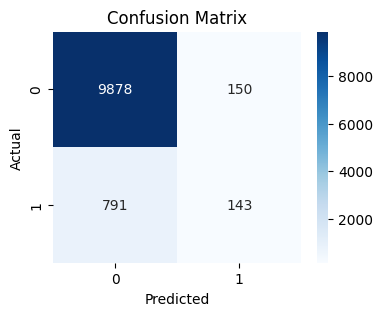

🚀 Training XGBoost...
✅ XGBoost evaluation results:
Accuracy: 0.9239

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96     10028
           1       0.84      0.13      0.23       934

    accuracy                           0.92     10962
   macro avg       0.88      0.56      0.59     10962
weighted avg       0.92      0.92      0.90     10962



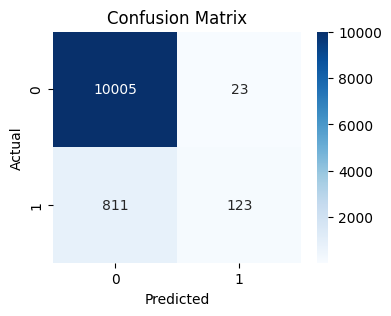

In [4]:
# =====================================
# 🧩 4. Train multiple models
# =====================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    )
}
 
results = {}

for name, model in models.items():
    print("="*60)
    print(f"🚀 Training {name}...")
    model.fit(X_train, y_train)
    print(f"✅ {name} evaluation results:")
    acc = evaluate_model(model, X_val, y_val)
    results[name] = acc


faltoooooooooooooooooooo

faltooooo

In [5]:
from sklearn.model_selection import cross_val_score

cv_results = {}

for name, model in models.items():
    print("="*70)
    print(f"🔁 Performing 5-fold Cross Validation for {name}...")
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"Mean CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    cv_results[name] = {
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std()
    }


🔁 Performing 5-fold Cross Validation for Logistic Regression...
Mean CV Accuracy: 0.9150 ± 0.0001
🔁 Performing 5-fold Cross Validation for Random Forest...
Mean CV Accuracy: 0.9134 ± 0.0015
🔁 Performing 5-fold Cross Validation for XGBoost...
Mean CV Accuracy: 0.9229 ± 0.0011


faltooooooooooooooooo

,Validation Accuracy,CV Mean Accuracy,CV Std
XGBoost,0.923919,0.922866,0.001132
Logistic Regression,0.914888,0.914975,0.000093
Random Forest,0.914158,0.913447,0.001472


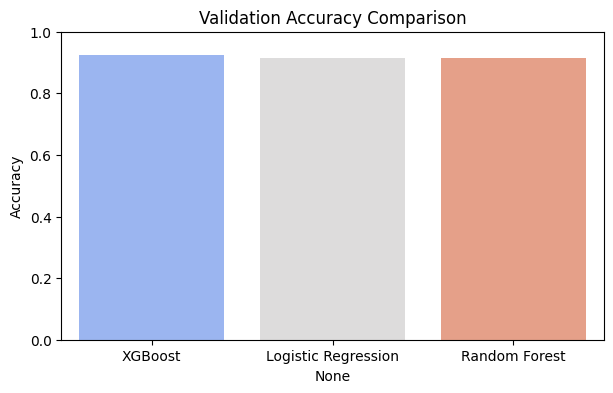

🏆 Best Model: XGBoost with Val Acc = 0.9239


In [6]:
# =====================================
# 📊 5. Compare accuracies
# =====================================

combined_results = pd.DataFrame({
    "Validation Accuracy": results,
    "CV Mean Accuracy": {k: v["cv_mean"] for k, v in cv_results.items()},
    "CV Std": {k: v["cv_std"] for k, v in cv_results.items()}
})

combined_results.sort_values(by="Validation Accuracy", ascending=False, inplace=True)
display(combined_results)

# Plot comparison
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))
sns.barplot(x=combined_results.index, y=combined_results["Validation Accuracy"], palette="coolwarm")
plt.title("Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# ✅ Define the best model name and instance
best_model_name = combined_results.index[0]
print(f"🏆 Best Model: {best_model_name} with Val Acc = {combined_results.loc[best_model_name, 'Validation Accuracy']:.4f}")
best_model = models[best_model_name]


faltoooooooooooooooo

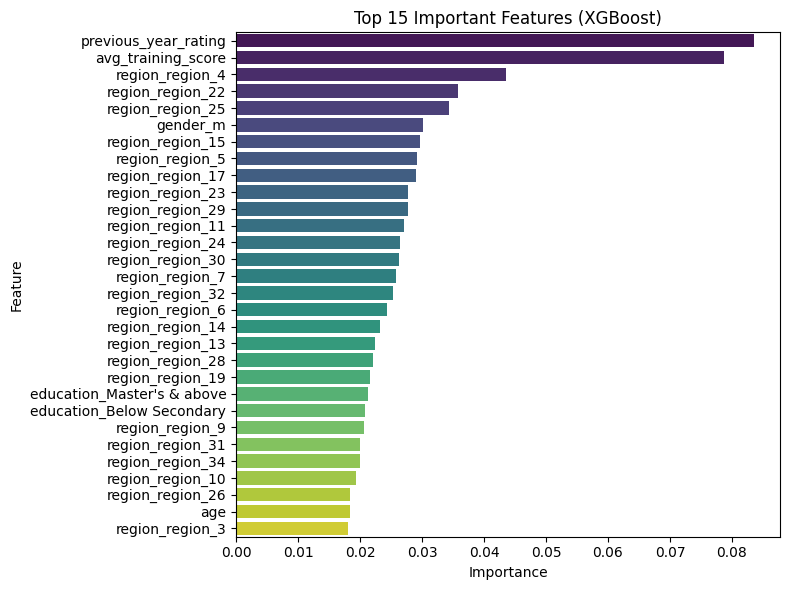

In [7]:
if best_model_name in ["Random Forest", "XGBoost"]:
    importances = best_model.feature_importances_
    fi_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)
    
    plt.figure(figsize=(8,6))
    sns.barplot(y="Feature", x="Importance", data=fi_df.head(30),palette="viridis")
    plt.title(f"Top 15 Important Features ({best_model_name})")
    plt.tight_layout()
    plt.show()


In [ ]:
# -------------------- IMPORT LIBRARIES --------------------
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# -------------------- LOAD DATA --------------------
processed_train = pd.read_csv("processed_train.csv")
processed_val = pd.read_csv("processed_val.csv")
y_val = pd.read_csv("y_val.csv").values.ravel()
y_train = pd.read_csv("y_train.csv").values.ravel()

# -------------------- DEFINE & TRAIN SVM MODEL --------------------
svm_model = SVC(
    C=1.0,            # Regularization parameter
    kernel='rbf',     # Radial basis function kernel
    gamma='scale',    # Kernel coefficient
    random_state=42
)

svm_model.fit(processed_train, y_train)

# -------------------- EVALUATE MODEL --------------------
y_pred = svm_model.predict(processed_val)

print("\n✅ Model Evaluation")
print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))





✅ Model Evaluation
Validation Accuracy: 0.9147965699689837

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.96     10028
           1       0.00      0.00      0.00       934

    accuracy                           0.91     10962
   macro avg       0.46      0.50      0.48     10962
weighted avg       0.84      0.91      0.87     10962


Confusion Matrix:
 [[10028     0]
 [  934     0]]

💾 Model saved successfully as svm_model.joblib


c:\Users\HP\OneDrive\Desktop\Classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\OneDrive\Desktop\Classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\OneDrive\Desktop\Classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

In [5]:
# -------------------- IMPORT LIBRARIES --------------------
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# -------------------- DEFINE & TRAIN MODEL --------------------
model = CatBoostClassifier(
    iterations=500,           # total boosting rounds
    learning_rate=0.05,       # step size
    depth=6,                  # tree depth
    eval_metric='Accuracy',   # evaluation metric
    random_seed=42,
    verbose=100,              # show training progress
    
)

model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

# -------------------- EVALUATE MODEL --------------------
y_pred = model.predict(X_val)

print("\n✅ Model Evaluation")
print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))

# -------------------- SAVE MODEL (Optional) --------------------
model.save_model("catboost_hr_model.cbm")

print("\n🎯 Model training complete & saved as 'catboost_hr_model.cbm'")


0:	learn: 0.9208594	test: 0.9216384	best: 0.9216384 (0)	total: 221ms	remaining: 1m 50s
100:	learn: 0.9236646	test: 0.9241014	best: 0.9242839 (44)	total: 2.23s	remaining: 8.79s
200:	learn: 0.9239839	test: 0.9239190	best: 0.9242839 (44)	total: 4.36s	remaining: 6.49s
300:	learn: 0.9246453	test: 0.9241014	best: 0.9242839 (44)	total: 6.46s	remaining: 4.27s
400:	learn: 0.9252155	test: 0.9241014	best: 0.9242839 (44)	total: 8.16s	remaining: 2.01s
499:	learn: 0.9257401	test: 0.9240102	best: 0.9242839 (44)	total: 9.98s	remaining: 0us

bestTest = 0.9242838898
bestIteration = 44

Shrink model to first 45 iterations.

✅ Model Evaluation
Accuracy: 0.9242838898011312

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     10028
           1       0.93      0.12      0.21       934

    accuracy                           0.92     10962
   macro avg       0.93      0.56      0.59     10962
weighted avg       0.92      0.92      0.9

In [6]:
# Load processed test data
X_test_final = pd.read_csv("processed_test.csv")

# Predict using the best model
test_preds = model.predict(X_test_final)

# Save predictions
pd.DataFrame({"Prediction": test_preds}).to_csv("test_predictions.csv", index=False)

print("✅ Test predictions saved to data/test_predictions.csv")


✅ Test predictions saved to data/test_predictions.csv


Dropping irrelevant columns (e.g., employee_id)

Filling missing values (for both numeric & categorical features)

Detecting categorical columns and passing them via cat_features

Train-test split

In [ ]:
# -------------------- IMPORT LIBRARIES --------------------
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------- LOAD DATA --------------------

train = pd.read_csv("train_data.csv")

# -------------------- DROP IRRELEVANT COLUMNS --------------------
cols_to_drop = ['employee_id', 'department', 'recruitment_channel']
train = train.drop(columns=cols_to_drop, errors='ignore')

# -------------------- TRAIN-TEST SPLIT --------------------
X = train.drop('is_promoted', axis=1)
y = train['is_promoted']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------- HANDLE MISSING VALUES --------------------
# Fill 'education' missing values with mode
if 'education' in X_train.columns:
    edu_mode = X_train['education'].mode()[0]
    X_train['education'] = X_train['education'].fillna(edu_mode)
    X_val['education'] = X_val['education'].fillna(edu_mode)

# Fill 'previous_year_rating' missing values with 0
if 'previous_year_rating' in X_train.columns:
    X_train['previous_year_rating'] = X_train['previous_year_rating'].fillna(0)
    X_val['previous_year_rating'] = X_val['previous_year_rating'].fillna(0)

# Fill numeric columns with median
for col in X_train.select_dtypes(include=[np.number]).columns:
    X_train[col] = X_train[col].fillna(X_train[col].median())
    X_val[col] = X_val[col].fillna(X_train[col].median())

# Fill categorical columns with "NA"
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].fillna("NA")
    X_val[col] = X_val[col].fillna("NA")

print("✅ Preprocessing complete!")

# -------------------- IDENTIFY CATEGORICAL FEATURES --------------------
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
print("Categorical features:", cat_features)

# -------------------- DEFINE & TRAIN CATBOOST MODEL --------------------
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='Accuracy',
    random_seed=42,
    verbose=100,
    cat_features=cat_features,
    early_stopping_rounds=50  # prevents overfitting
)

model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

# -------------------- EVALUATE MODEL --------------------
y_pred = model.predict(X_val)

print("\n🎯 Model Evaluation")
print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))



# -------------------- FEATURE IMPORTANCE --------------------
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:\n", feature_importances.head(10))


✅ Preprocessing complete!
Categorical features: ['region', 'education', 'gender']
0:	learn: 0.9224103	test: 0.9223682	best: 0.9223682 (0)	total: 250ms	remaining: 2m 4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9263820471
bestIteration = 44

Shrink model to first 45 iterations.

🎯 Model Evaluation
Accuracy: 0.9263820470717022

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96     10028
           1       0.92      0.15      0.26       934

    accuracy                           0.93     10962
   macro avg       0.92      0.57      0.61     10962
weighted avg       0.93      0.93      0.90     10962


Confusion Matrix:
 [[10015    13]
 [  794   140]]

Top 10 Important Features:
                 Feature  Importance
9    avg_training_score   44.900038
7         KPIs_met >80%   40.107140
5  previous_year_rating    8.244342
8           awards_won?    2.993665
0                region    1.071613

In [9]:
cat_features

['region', 'education', 'gender']

In [8]:
# -------------------- SAVE MODEL --------------------
model.save_model("catboost_model.cbm")
print("\n✅ Model saved as 'catboost_model.cbm'")


✅ Model saved as 'catboost_model.cbm'


In [ ]:
# -------------------- IMPORT LIBRARIES --------------------
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder

# -------------------- LOAD DATA --------------------
train = pd.read_csv("train_data.csv")

# -------------------- DROP IRRELEVANT COLUMNS --------------------
cols_to_drop = ['employee_id', 'department', 'recruitment_channel']
train = train.drop(columns=cols_to_drop, errors='ignore')

# -------------------- TRAIN-TEST SPLIT --------------------
X = train.drop('is_promoted', axis=1)
y = train['is_promoted']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------- HANDLE MISSING VALUES --------------------
# Fill 'education' missing values with mode
if 'education' in X_train.columns:
    edu_mode = X_train['education'].mode()[0]
    X_train['education'] = X_train['education'].fillna(edu_mode)
    X_val['education'] = X_val['education'].fillna(edu_mode)

# Fill 'previous_year_rating' missing values with 0
if 'previous_year_rating' in X_train.columns:
    X_train['previous_year_rating'] = X_train['previous_year_rating'].fillna(0)
    X_val['previous_year_rating'] = X_val['previous_year_rating'].fillna(0)

# Fill numeric columns with median
for col in X_train.select_dtypes(include=[np.number]).columns:
    X_train[col] = X_train[col].fillna(X_train[col].median())
    X_val[col] = X_val[col].fillna(X_train[col].median())

# Fill categorical columns with "NA"
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].fillna("NA")
    X_val[col] = X_val[col].fillna("NA")

print("✅ Preprocessing complete!")

# -------------------- IDENTIFY CATEGORICAL FEATURES --------------------
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
print("Categorical features:", cat_features)

# -------------------- HANDLE CLASS IMBALANCE --------------------
pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])
print("⚖️ Scale_pos_weight =", pos_weight)

# -------------------- DEFINE & TRAIN CATBOOST MODEL --------------------
model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    eval_metric='F1',
    random_seed=42,
    verbose=200,
    cat_features=cat_features,
    early_stopping_rounds=100,
    scale_pos_weight=pos_weight  # helps balance minority class
)

model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

# -------------------- EVALUATE MODEL --------------------
y_pred_prob = model.predict_proba(X_val)[:, 1]

# Tune threshold for best F1
best_thresh = 0.5
best_f1 = 0
for thresh in np.arange(0.2, 0.8, 0.02):
    f1 = f1_score(y_val, (y_pred_prob > thresh).astype(int))
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

y_pred = (y_pred_prob > best_thresh).astype(int)

print("\n🎯 Model Evaluation")
print("Best Threshold:", best_thresh)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))

# -------------------- FEATURE IMPORTANCE --------------------
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:\n", feature_importances.head(10))


✅ Preprocessing complete!
Categorical features: ['region', 'education', 'gender']
⚖️ Scale_pos_weight = 10.742367434386717
0:	learn: 0.7844581	test: 0.7745650	best: 0.7745650 (0)	total: 128ms	remaining: 3m 11s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7798507508
bestIteration = 39

Shrink model to first 40 iterations.

🎯 Model Evaluation
Best Threshold: 0.6799999999999997
Accuracy: 0.8952745849297573
F1 Score: 0.3699231613611416

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.94     10028
           1       0.38      0.36      0.37       934

    accuracy                           0.90     10962
   macro avg       0.66      0.65      0.66     10962
weighted avg       0.89      0.90      0.89     10962


Confusion Matrix:
 [[9477  551]
 [ 597  337]]

Top 10 Important Features:
                 Feature  Importance
9    avg_training_score   41.853071
7         KPIs_met >80%   38.182149
5  p

In [14]:
# -------------------- SAVE MODEL --------------------
model.save_model("catboost_hr_model.cbm")
print("💾 Model saved successfully as 'catboost_hr_model.cbm'")


💾 Model saved successfully as 'catboost_hr_model.cbm'


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


models = ['CatBoost','XGBoost' 'Random Forest', 'SVM', 'Logistic Regression']


accuracy = [0.8952,0.9239,0.9142,0.9147,0.9149]
f1_score = [0.37,0.23,0.23,0.00,0.00]
precision = [0.38, 0.84, 0.49,0.00, 1.00]
recall = [0.36, 0.13,0.15,0.00,0.00]

# Create bar positions
x = np.arange(len(models))
width = 0.2

# Plot
plt.figure(figsize=(10,6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, f1_score, width, label='F1 Score')
plt.bar(x + 0.5*width, precision, width, label='Precision')
plt.bar(x + 1.5*width, recall, width, label='Recall')

# Style
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Validation Metrics Comparison')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()
